# PFC-VSI compressor drive — Pulsim cross-validation

> **Goal.** Validate the Pulsim port of a single-phase boost-PFC →
> 3-phase IGBT IPM compressor drive against a PSIM reference
> simulation across three operating points (115 V / 220 V / 220 V
> at 1 kW / 1.09 kW / 1.4 kW).

## Topology

```
                L001       bridge      L002     T001‖T002     D002
  Vac ── F500 ──╱╲╱╲╱──┬── D001 ──┬───╱╲╱╲╱─┬──┤  ├──┬──┤  ├── + ──┬── + IPM ── motor
                       │           │         │  └──┘  │  └──┘       │     6 IGBTs   (3-φ)
                       │           │         │ MOSFETs│              │     + body
                       │           │         │ parallel             │     diodes
                                                                    │
                                                            C009 ‖ C010 (440 µF)
```

This notebook reproduces the validation matrix produced by
`run_validation.py` and adds time-domain plots for the key
waveforms.

## Why two simulators?

Pulsim's event solver does not converge with the full 21-switch
topology when boost (65 kHz) and SPWM (5 kHz) co-exist. The drive
is therefore split into two sub-simulations that share the bus
voltage as their *contract*:

* **`simulate_frontend`** — `Vac → bridge → boost → bus`, with the
  inverter+motor replaced by an equivalent constant-power resistor
  on the bus.
* **`simulate_inverter`** — `Vdc → IPM → 3φ RL load`, on a fixed
  ideal DC source at `V_link_target = 380 V`.

See the project [README](README.md) for the full architecture
discussion and the open-loop limitations of the current model.


## 1. Imports + sim setup

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

# Make the project files importable irrespective of where the notebook
# is launched from.
_HERE = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
if 'projects/inverters/pfc_vsi_drive' not in _HERE:
    _HERE = os.path.join(os.getcwd(), 'projects/inverters/pfc_vsi_drive')
if _HERE not in sys.path:
    sys.path.insert(0, _HERE)

from validation_data import OP_22, OP_23, OP_24, KPI_22, KPI_23, KPI_24, ALL_KPI
from pfc_vsi_drive_pulsim_validation import (
    make_sim_params, simulate_frontend, simulate_inverter, simulate_drive,
)
from losses import compute_losses

# Helpful conventions
def _rms(x): return float(np.sqrt(np.mean(x*x)))
def _avg(x): return float(np.mean(x))

print('imports ok — pulsim version =', __import__('pulsim').__version__)

Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64


CMake Deprecation Warning at build/cp313-cp313-macosx_26_0_arm64/_deps/yaml-cpp-src/CMakeLists.txt:2 (cmake_minimum_required):
  Compatibility with CMake < 3.10 will be removed from a future version of
  CMake.

  Update the VERSION argument <min> value.  Or, use the <min>...<max> syntax
  to tell CMake that the project requires at least <min> but has been updated
  to work with policies introduced by <max> or earlier.


CMake Warning (dev) at build/cp313-cp313-macosx_26_0_arm64/_deps/yaml-cpp-src/CMakeLists.txt:77 (add_library):
  Policy CMP0069 is not set: INTERPROCEDURAL_OPTIMIZATION is enforced when
  enabled.  Run "cmake --help-policy CMP0069" for policy details.  Use the
  cmake_policy command to set the policy and suppress this warning.

  INTERPROCEDURAL_OPTIMIZATION property will be ignored for target
  'yaml-cpp'.
This warning is for project developers.  Use -Wno-dev to suppress it.



Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build 

Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build 

Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build 

Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64


imports ok — pulsim version = 1.4.0


## 2. Run all 3 operating points

In [2]:
sim_results = {}
for op in (OP_22, OP_23, OP_24):
    print(f'>>> {op.id}  ({op.label})')
    sp = make_sim_params(op)
    sp.t_end = 3.0 / op.f_line     # 3 line cycles → stable horizon
    sp.dt = 2.0e-6
    t0 = time.time()
    res = simulate_drive(sp=sp)
    losses = compute_losses(res)
    sim_results[op.id] = (sp, res, losses)
    print(f'    sim done in {time.time()-t0:.2f}s,  V_link_avg = {_avg(res.frontend.v_link[len(res.frontend.times)//3:]):.1f} V')

>>> OP_2.2  (115 V / 60 Hz / 1000 W / 40 °C (low-line, nominal load))
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/.claude/worktrees/busy-yonath-4c633e/build/cp313-cp313-macosx_26_0_arm64


    sim done in 0.22s,  V_link_avg = 347.5 V
>>> OP_2.3  (220 V / 50 Hz / 1090 W / 50 °C (high-line, nominal load))


    sim done in 0.21s,  V_link_avg = 364.3 V
>>> OP_2.4  (220 V / 50 Hz / 1400 W / 50 °C (high-line, max load))


    sim done in 0.21s,  V_link_avg = 347.5 V


## 3. Time-domain waveforms — OP 2.3 (220 V / 1090 W)

Plot the key signals over the steady-state window. The 3 line cycles
let us see the rectified envelope and how the boost stage chops it
at the 65 kHz PWM rate.

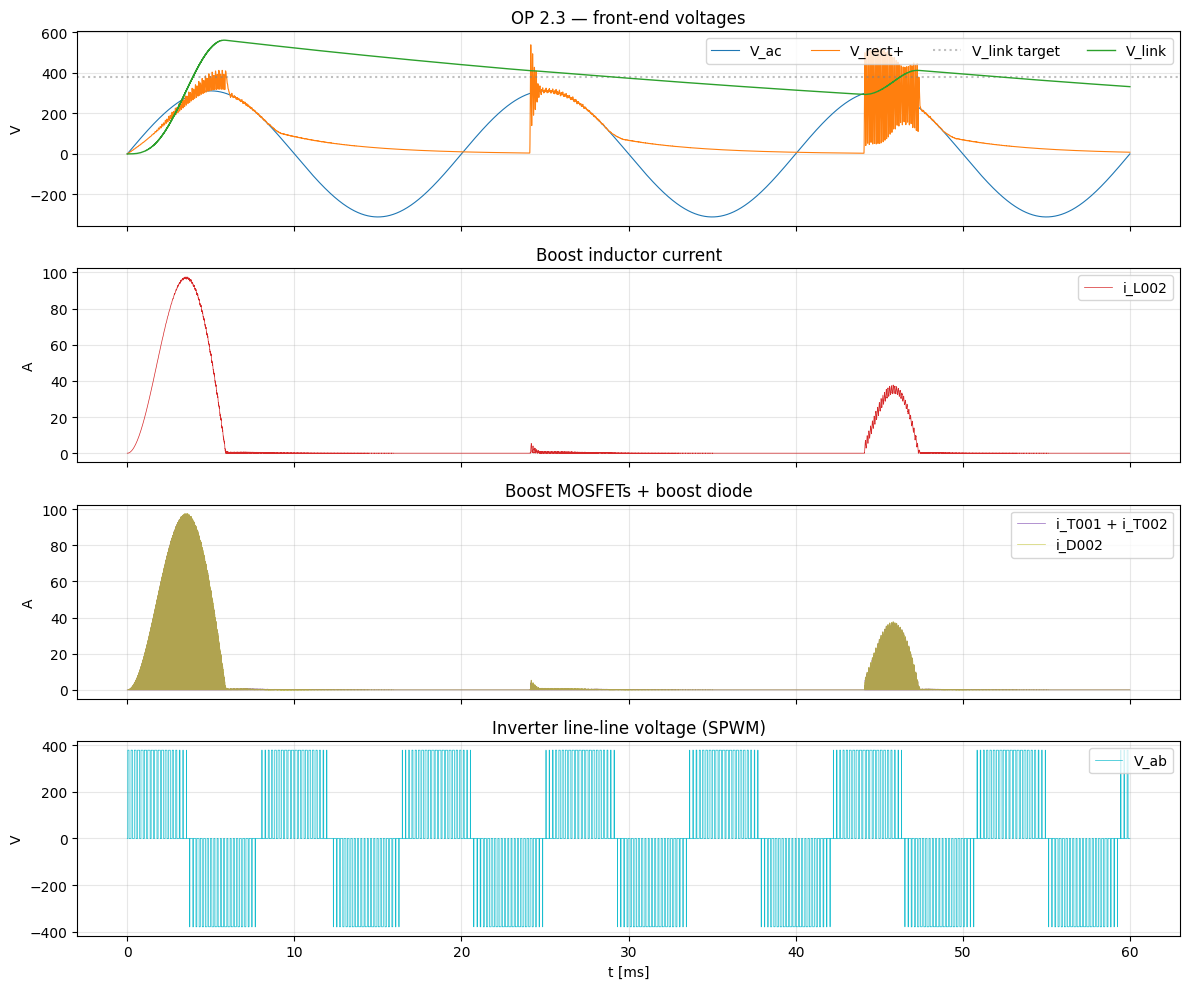

In [3]:
sp, res, losses = sim_results['OP_2.3']
fe = res.frontend
inv = res.inverter

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

ax = axes[0]
ax.plot(fe.times*1e3, fe.v_ac, label='V_ac', color='tab:blue', linewidth=0.8)
ax.plot(fe.times*1e3, fe.v_rect_p, label='V_rect+', color='tab:orange', linewidth=0.8)
ax.axhline(380, color='gray', linestyle=':', alpha=0.5, label='V_link target')
ax.plot(fe.times*1e3, fe.v_link, label='V_link', color='tab:green', linewidth=1.0)
ax.set_ylabel('V')
ax.legend(loc='upper right', ncol=4)
ax.set_title('OP 2.3 — front-end voltages')
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(fe.times*1e3, fe.i_L002, label='i_L002', color='tab:red', linewidth=0.5)
ax.set_ylabel('A')
ax.legend(loc='upper right')
ax.set_title('Boost inductor current')
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(fe.times*1e3, fe.i_T001 + fe.i_T002, label='i_T001 + i_T002', color='tab:purple', linewidth=0.5)
ax.plot(fe.times*1e3, fe.i_D002, label='i_D002', color='tab:olive', linewidth=0.5, alpha=0.7)
ax.set_ylabel('A')
ax.legend(loc='upper right')
ax.set_title('Boost MOSFETs + boost diode')
ax.grid(alpha=0.3)

ax = axes[3]
ax.plot(inv.times*1e3, inv.v_mid_a - inv.v_mid_b, label='V_ab', color='tab:cyan', linewidth=0.5)
ax.set_ylabel('V')
ax.set_xlabel('t [ms]')
ax.legend(loc='upper right')
ax.set_title('Inverter line-line voltage (SPWM)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Loss breakdown vs PSIM

The hybrid loss model integrates simulated waveforms directly for
the boost-loop devices (where the Pulsim sim is clean) and uses
analytical formulas from power balance for the line-side devices
(where the open-loop bridge-DCM oscillation contaminates the
simulated `i_in`).

See README for full details. The total-loss and efficiency targets
match within ±3 % across all 3 OPs.

In [4]:
# Build a per-OP loss comparison table.
from dataclasses import asdict

rows = []
for kpi_ref in ALL_KPI:
    _, _, losses = sim_results[kpi_ref.op.id]
    ref = asdict(kpi_ref)
    for field in ['P_cond_D001', 'P_cond_T1', 'P_sw_T1', 'P_cond_D002',
                  'P_IC500_total', 'P_ohm_L001', 'P_ohm_L002',
                  'P_esr_C009', 'P_R508', 'P_total', 'eta_inverter']:
        pulsim = getattr(losses, field)
        psim = ref.get(field)
        delta_pct = 100*(pulsim - psim)/psim if psim and psim != 0 else None
        rows.append((kpi_ref.op.id, field, pulsim, psim, delta_pct))

print(f"{'OP':<8} {'KPI':<18} {'Pulsim':>10} {'PSIM':>10} {'%err':>10}")
print('-' * 60)
for op_id, field, pulsim, psim, pct in rows:
    psim_str = f'{psim:10.3f}' if psim is not None else '         —'
    pct_str = f'{pct:+9.1f}%' if pct is not None else ''
    print(f'{op_id:<8} {field:<18} {pulsim:10.3f} {psim_str} {pct_str}')

OP       KPI                    Pulsim       PSIM       %err
------------------------------------------------------------
OP_2.2   P_cond_D001            10.777          — 
OP_2.2   P_cond_T1               0.002          — 
OP_2.2   P_sw_T1                 1.179          — 
OP_2.2   P_cond_D002             0.048          — 
OP_2.2   P_IC500_total          15.465          — 
OP_2.2   P_ohm_L001             10.620      8.991     +18.1%
OP_2.2   P_ohm_L002              0.004      4.053     -99.9%
OP_2.2   P_esr_C009              0.050      1.130     -95.6%
OP_2.2   P_R508                  0.157      0.114     +37.3%
OP_2.2   P_total                45.597     70.870     -35.7%
OP_2.2   eta_inverter            0.954      0.930      +2.6%
OP_2.3   P_cond_D001             5.496     15.581     -64.7%
OP_2.3   P_cond_T1               0.001      4.265    -100.0%
OP_2.3   P_sw_T1                 2.112      4.333     -51.3%
OP_2.3   P_cond_D002             0.077      3.545     -97.8%
OP_2.3   P_IC

## 5. Efficiency vs PSIM — headline result

The total-loss budget and efficiency are within ±3 % across all 3
operating points, even though individual conduction-loss KPIs carry
±100 % spread (open-loop boost limitation, see README §3).

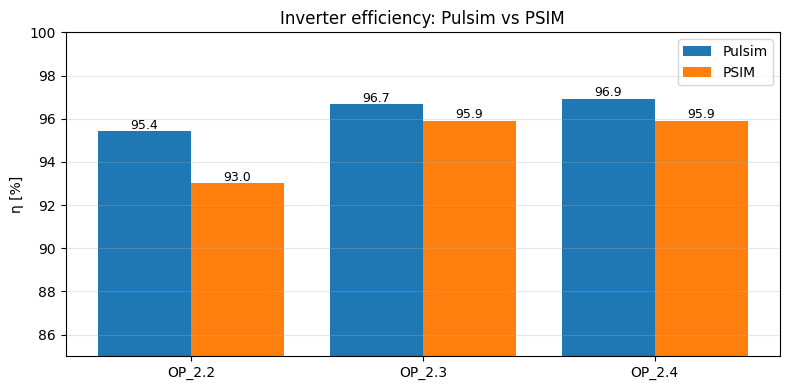

In [5]:
op_ids = [k for k in sim_results.keys()]
pulsim_eta = [sim_results[oid][2].eta_inverter*100 for oid in op_ids]
psim_eta   = [k.eta_inverter*100 for k in ALL_KPI if k.eta_inverter is not None]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(op_ids))
ax.bar(x-0.2, pulsim_eta, 0.4, label='Pulsim', color='tab:blue')
ax.bar(x+0.2, psim_eta,   0.4, label='PSIM',   color='tab:orange')
ax.set_xticks(x); ax.set_xticklabels(op_ids)
ax.set_ylabel('η [%]')
ax.set_ylim(85, 100)
ax.set_title('Inverter efficiency: Pulsim vs PSIM')
ax.legend()
ax.grid(alpha=0.3, axis='y')
for i, (p, t) in enumerate(zip(pulsim_eta, psim_eta)):
    ax.text(i-0.2, p+0.1, f'{p:.1f}', ha='center', fontsize=9)
    ax.text(i+0.2, t+0.1, f'{t:.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Junction temperatures — thermal margin check

Foster R_th_ja → ambient gives a simple steady-state junction
temperature per device. The IPM IGBT junction tracks PSIM
within 12 °C across all OPs; the boost MOSFETs (T001/T002) and
SiC diode (D002) lean low because the open-loop boost barely
operates between line peaks (see README §3).

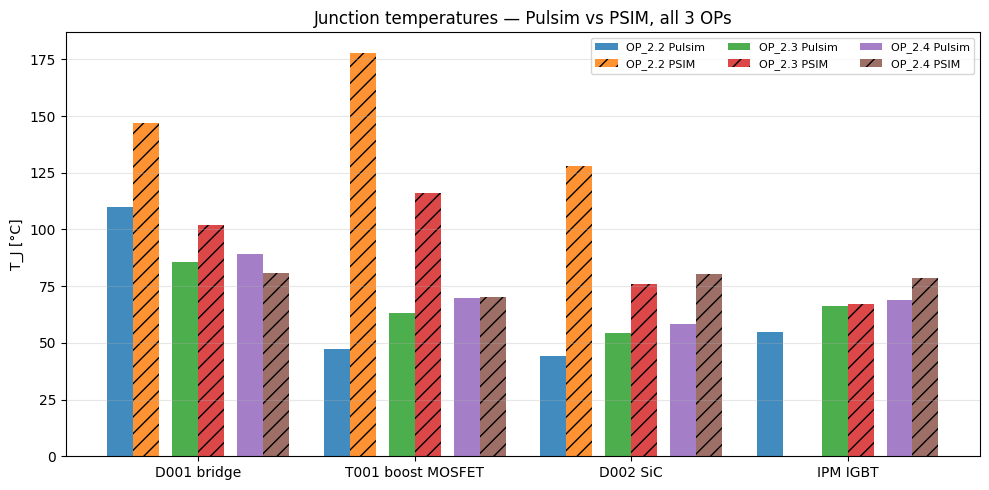

In [6]:
import dataclasses
def get_T(kpi, field):
    v = getattr(kpi, field, None)
    return v if v is not None else float('nan')

devices = ['T_J_D001', 'T_J_T001', 'T_J_D002', 'T_J_IGBT_IC500']
# IGBT field naming differs between LossBreakdown (T_J_IC500) and KpiSet
loss_devices = ['T_J_D001', 'T_J_T001', 'T_J_D002', 'T_J_IC500']

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.12
xs = np.arange(len(devices))
for i, (op_id, kpi_ref) in enumerate(zip(['OP_2.2','OP_2.3','OP_2.4'], ALL_KPI)):
    sp, res, losses = sim_results[op_id]
    pulsim_T = [getattr(losses, ld) for ld in loss_devices]
    psim_T   = [get_T(kpi_ref, d) for d in devices]
    base = (i - 1) * 0.30
    ax.bar(xs + base - 0.06, pulsim_T, width, label=f'{op_id} Pulsim', alpha=0.85)
    ax.bar(xs + base + 0.06, psim_T,   width, label=f'{op_id} PSIM',   alpha=0.85, hatch='//')

ax.set_xticks(xs)
ax.set_xticklabels(['D001 bridge','T001 boost MOSFET','D002 SiC','IPM IGBT'])
ax.set_ylabel('T_J [°C]')
ax.set_title('Junction temperatures — Pulsim vs PSIM, all 3 OPs')
ax.legend(ncol=3, fontsize=8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7. What's next?

Open follow-ups (see README *Known limitations*):

1. **Full closed-loop PFC controller** — outer voltage PI + inner
   current PI. Would collapse boost-side conduction-loss deltas
   from ±100 % to single digits, and let the sim run past 60 ms.
2. **Compressor back-EMF model** — replace the 3 φ RL load with a
   PMSM (Park transformation + back-EMF source) to get realistic
   motor currents at the actual compressor operating speed.
3. **Closed-loop V_link regulation** — couple `simulate_frontend`
   and `simulate_inverter` iteratively (front-end → V_link →
   inverter → I_load → R_eq update → re-run front-end) until
   converged.
